In [1]:
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
%matplotlib widget
from pyhtp.ellip import EllipDatabase, EllipSpectrum
from pyhtp.typing import SampleInfo

In [2]:
db = EllipDatabase(
    file_path=('data/GSTSe Ellipsometry/GSTSe-2_as.csv',
               'data/GSTSe Ellipsometry/GSTSe-2_300C.csv'),
    info=SampleInfo(
        name='GSTSe-2',
        element=['Se', 'Te', 'Ge', 'Sb'],
        film_thickness=[12.4, 7.6, 12.4, 7.6],
        temperature=(25, 300),
    )
)

[0, 83, 103, 113, 124, 134, 145, 166, 333, 374, 416, 457, 499, 509, 514, 519, 524, 529, 534, 540, 545, 550, 582, 592, 603, 613, 624, 645, 666]


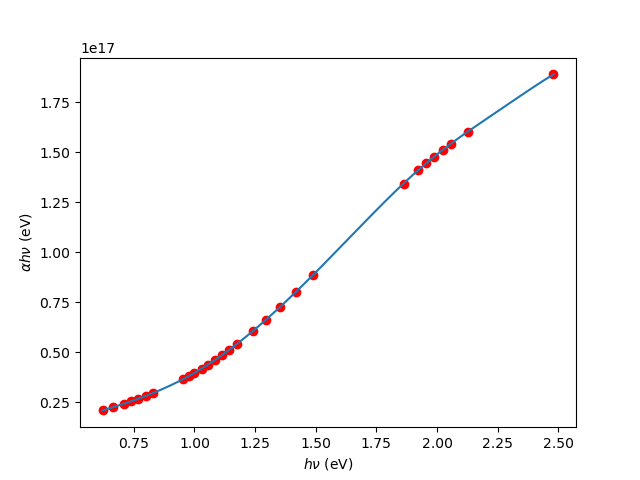

In [3]:
point1: EllipSpectrum = db.data[14].crystalline
section_index = point1._fit_linear(r2_tol=0.9999, angle_tol=0.001)
print(section_index)
# Plot the curve and section scatters
fig, ax = plt.subplots()
point1.plot_tauc(ax=ax)
freq = scipy.constants.c / (point1.wavelength * 1e-9)
x = scipy.constants.Planck * freq
y = point1.absorp * x ** 0.5
# Use ev as unit, original ones are use joule as unit.
x /= scipy.constants.e
y /= scipy.constants.e
ax.scatter(x[section_index], y[section_index], color='red')

In [ ]:
fom = db.fom
wavelength = db.wavelength

In [ ]:
fig, ax = plt.subplots()
cmap = matplotlib.colormaps['summer']
cmap1 = matplotlib.colormaps['winter']
for i in range(400):
    color = cmap(i / 400)
    color1 = cmap1(i / 400)
    #db.data[i].amorphous.plot_tauc(ax=ax, color=color, alpha=0.5, linewidth=0.5)
    db.data[i].crystalline.plot_tauc(ax=ax, color=color1, alpha=0.5, linewidth=0.5)
plt.show()

In [ ]:
amorphous_direct_allowed = np.array([d.amorphous.bandgap.direct_allowed for d in db.data])
crystalline_direct_allowed = np.array([d.crystalline.bandgap.direct_allowed for d in db.data])
print(amorphous_direct_allowed.shape)
print(crystalline_direct_allowed.shape)

In [ ]:
from pyhtp.quaternary import surf_quaternary

surf_quaternary(value=crystalline_direct_allowed.tolist(),
                label=('Ge', 'Sb', 'Se', 'Te'),
                database=db, path_type='snakelike')
surf_quaternary(value=amorphous_direct_allowed.tolist(),
                label=('Ge', 'Sb', 'Se', 'Te'),
                database=db, path_type='snakelike')